# Notebook 04 — BERT Fine-Tuned Classifier
**Goal:** Fine-tune `bert-base-uncased` on our labeled support tickets for multi-class classification. Beat the baseline Macro F1 from Notebook 03.

> **GPU Note:** Run this on Google Colab (free T4) if you don't have a local GPU.
> Runtime → Change runtime type → T4 GPU

In [1]:
# Free up RAM before loading anything
import gc
gc.collect()

# Check available RAM
import psutil
ram = psutil.virtual_memory()
print(f"Available RAM: {ram.available / 1024**3:.1f} GB")
print(f"Total RAM: {ram.total / 1024**3:.1f} GB")

Available RAM: 8.4 GB
Total RAM: 12.7 GB


In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cpu':
    print('WARNING: No GPU detected. Training will be slow. Consider Google Colab.')

Using device: cuda


## 1. Load Data

In [3]:
df = pd.read_csv('labeled_tickets.csv') # Assuming the file is uploaded to the Colab root directory
print(f'Loaded {len(df):,} rows')
print(df['category'].value_counts())

Loaded 80,000 rows
category
account_access       60977
general_complaint     7241
general_inquiry       3524
shipping_delivery     3503
billing_payment       3173
technical_issue       1582
Name: count, dtype: int64


## 2. Encode Labels & Subsample
We use the original (non-SMOTE) text for BERT — BERT handles imbalance better natively.
We cap at 30K samples for reasonable training time on a free Colab GPU (~25 min).

In [4]:
# Cap sample size for Colab feasibility — increase if you have more compute
MAX_SAMPLES = 15000
df = df.sample(min(MAX_SAMPLES, len(df)), random_state=42).reset_index(drop=True)

# Encode string labels to integers
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
id2label  = {v: k for k, v in label_map.items()}
num_labels = len(label_map)

print('Label mapping:', label_map)
print(f'Number of classes: {num_labels}')

Label mapping: {'account_access': np.int64(0), 'billing_payment': np.int64(1), 'general_complaint': np.int64(2), 'general_inquiry': np.int64(3), 'shipping_delivery': np.int64(4), 'technical_issue': np.int64(5)}
Number of classes: 6


## 3. Train/Val/Test Split

In [5]:
# Use original text (not clean_text) — BERT handles raw text well
X = df['text'].astype(str).tolist()
y = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')

Train: 12,000  |  Val: 1,500  |  Test: 1,500


## 4. Tokenize

In [6]:
MODEL_NAME = 'bert-base-uncased'
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)

MAX_LEN = 64  # Tweets are short — 128 is sufficient

def tokenize(texts):
    return tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)
print('Tokenization complete.')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete.


## 5. PyTorch Dataset

In [7]:
class TicketDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = TicketDataset(train_enc, y_train)
val_dataset   = TicketDataset(val_enc,   y_val)
test_dataset  = TicketDataset(test_enc,  y_test)
print(f'Datasets built — train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}')

Datasets built — train: 12000, val: 1500, test: 1500


## 6. Load BERT Model

In [8]:
fixed_id2label = {int(k): v for k, v in id2label.items()}
fixed_label2id = {k: int(v) for k, v in label_map.items()}

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=fixed_id2label,
    label2id=fixed_label2id
)
model.to(device)
print(f'Model loaded on {device}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda


## 7. Define Metrics

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro')
    }

## 8. Training Arguments & Trainer

In [10]:
training_args = TrainingArguments(
    output_dir='../outputs/bert_checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=50,
    fp16=(device == 'cuda'),  # mixed precision only on GPU
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print('Trainer ready. Starting training...')


Trainer ready. Starting training...


## 9. Train!
> **Expected time:** ~20-25 min on Colab T4 GPU with 30K samples, 3 epochs.

In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.196628,0.129671,0.973333,0.931881
2,0.066822,0.039258,0.989333,0.979335
3,0.035638,0.052693,0.988667,0.981923


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1125, training_loss=0.23915168571472167, metrics={'train_runtime': 189.1345, 'train_samples_per_second': 190.341, 'train_steps_per_second': 5.948, 'total_flos': 1184042271744000.0, 'train_loss': 0.23915168571472167, 'epoch': 3.0})

## 10. Evaluate on Test Set

In [12]:
test_results = trainer.evaluate(test_dataset)
print('\n=== TEST SET RESULTS ===')
print(f"Accuracy:  {test_results['eval_accuracy']:.4f}")
print(f"Macro F1:  {test_results['eval_macro_f1']:.4f}")


=== TEST SET RESULTS ===
Accuracy:  0.9867
Macro F1:  0.9774


## 11. Full Classification Report + Confusion Matrix

                   precision    recall  f1-score   support

   account_access       1.00      0.99      0.99      1139
  billing_payment       1.00      1.00      1.00        58
general_complaint       0.93      0.97      0.95       133
  general_inquiry       0.95      0.99      0.97        72
shipping_delivery       1.00      0.97      0.98        66
  technical_issue       0.94      1.00      0.97        32

         accuracy                           0.99      1500
        macro avg       0.97      0.99      0.98      1500
     weighted avg       0.99      0.99      0.99      1500



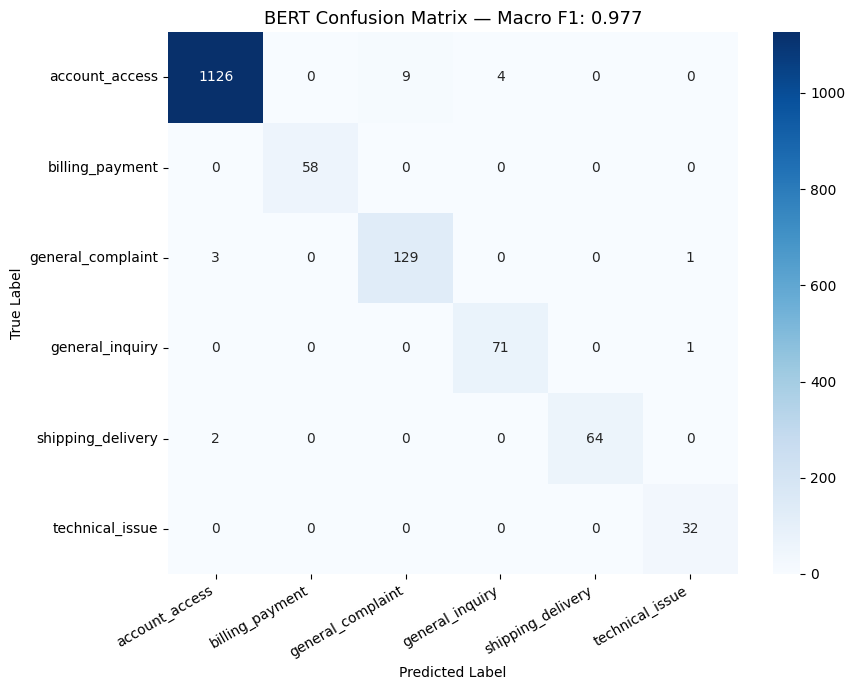

In [13]:
# Get predictions
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test)

print(classification_report(y_test_labels, y_pred_labels))

# Confusion matrix
categories = le.classes_
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=categories)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title(f'BERT Confusion Matrix — Macro F1: {f1_score(y_test_labels, y_pred_labels, average="macro"):.3f}',
          fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.show()

## 12. Baseline vs BERT Comparison

In [14]:
import os
bert_f1 = f1_score(y_test_labels, y_pred_labels, average='macro')

baseline_path = '../outputs/baseline_results.csv'
if os.path.exists(baseline_path):
    baseline = pd.read_csv(baseline_path)
    best_baseline_f1 = baseline['Macro F1'].max()
    improvement = ((bert_f1 - best_baseline_f1) / best_baseline_f1) * 100

    comparison = pd.concat([
        baseline,
        pd.DataFrame({'Model': ['BERT (fine-tuned)'],
                      'Accuracy': [round(test_results['eval_accuracy'], 4)],
                      'Macro F1': [round(bert_f1, 4)]})
    ], ignore_index=True)

    print(comparison.to_string(index=False))
    print(f'\nBERT improvement over best baseline: +{improvement:.1f}%')
    comparison.to_csv('../outputs/model_comparison.csv', index=False)
else:
    print(f'BERT Macro F1: {bert_f1:.4f}')
    print('Run Notebook 03 first to generate baseline_results.csv')

BERT Macro F1: 0.9774
Run Notebook 03 first to generate baseline_results.csv


## 13. Save Model & Tokenizer

In [26]:
import os

# Ensure the output directory exists
os.makedirs('/content/outputs', exist_ok=True)

model.save_pretrained('/content/outputs/bert_model')
tokenizer.save_pretrained('/content/outputs/bert_model')

import joblib
joblib.dump(le, '/content/outputs/label_encoder.joblib')

print('Saved: /content/outputs/bert_model/')
print('Saved: /content/outputs/label_encoder.joblib')
print('Next: Notebook 05 — Routing Engine')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/outputs/bert_model/
Saved: /content/outputs/label_encoder.joblib
Next: Notebook 05 — Routing Engine


### Accessing and Downloading Saved Files

YouYou can download individual files using `google.colab.files.download` and directories by first zipping them.

In [28]:
import shutil
from google.colab import files
import os

# Create the target directory for zipping
os.makedirs('/content/bert_outputs', exist_ok=True)

# Define source paths
bert_model_source_path = '/content/outputs/bert_model'
label_encoder_source_path = '/content/outputs/label_encoder.joblib'
model_comparison_source_path = '/content/outputs/model_comparison.csv'

# Copy key files into one folder, checking for existence first
if os.path.exists(bert_model_source_path):
    shutil.copytree(bert_model_source_path, '/content/bert_outputs/bert_model',
                    dirs_exist_ok=True)
else:
    print(f'Warning: {bert_model_source_path} not found. Skipping BERT model copy. Please ensure the model was saved correctly (check cell g0zykAq1VaJR).')

if os.path.exists(label_encoder_source_path):
    shutil.copy(label_encoder_source_path, '/content/bert_outputs/')
else:
    print(f'Warning: {label_encoder_source_path} not found. Skipping label encoder copy. Please ensure the label encoder was saved correctly (check cell g0zykAq1VaJR).')

if os.path.exists(model_comparison_source_path):
    shutil.copy(model_comparison_source_path, '/content/bert_outputs/')
else:
    print(f'Warning: {model_comparison_source_path} not found. Skipping model comparison CSV copy.')

# Zip and download
# Check if the directory to be zipped is not empty to avoid creating empty zip
if os.listdir('/content/bert_outputs'):
    shutil.make_archive('/content/bert_outputs_final', 'zip', '/content/bert_outputs')
    files.download('/content/bert_outputs_final.zip')
    print('Download complete: bert_outputs_final.zip')
else:
    print('No files were copied to /content/bert_outputs. Skipping zip and download.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete: bert_outputs_final.zip


In [27]:
import os

print('Contents of /content/outputs/ :')
print(os.listdir('/content/outputs/'))

print('\nContents of /content/outputs/bert_model/ :')
if os.path.exists('/content/outputs/bert_model'):
    print(os.listdir('/content/outputs/bert_model'))
else:
    print('Directory /content/outputs/bert_model does not exist.')

print('\nChecking for label_encoder.joblib:')
if os.path.exists('/content/outputs/label_encoder.joblib'):
    print('label_encoder.joblib FOUND.')
else:
    print('label_encoder.joblib NOT FOUND.')

print('\nChecking for model_comparison.csv:')
if os.path.exists('/content/outputs/model_comparison.csv'):
    print('model_comparison.csv FOUND.')
else:
    print('model_comparison.csv NOT FOUND. Remember this file is created if you ran Notebook 03 first.')

Contents of /content/outputs/ :
['bert_model', 'label_encoder.joblib']

Contents of /content/outputs/bert_model/ :
['model.safetensors', 'tokenizer.json', 'config.json', 'tokenizer_config.json']

Checking for label_encoder.joblib:
label_encoder.joblib FOUND.

Checking for model_comparison.csv:
model_comparison.csv NOT FOUND. Remember this file is created if you ran Notebook 03 first.


In [22]:
print('Checking if df is loaded...')
display(df.head(3))

Checking if df is loaded...


,tweet_id,author_id,created_at,text,clean_text,category,priority,sentiment_neg,text_length,word_count,label
0,2804421,782219.0,2017-11-22 02:09:03+00:00,@AppleSupport @107623 @107624 On iPhone X iOS ...,on iphone x ios battle bay v,account_access,1,0.191,76.0,12.0,0
1,1939239,576846.0,2017-10-18 15:24:10+00:00,Anyone else experiencing delayed response on i...,anyone else experiencing delayed response on i...,account_access,1,0.139,113.0,15.0,0
2,697583,198354.0,2017-10-11 01:29:12+00:00,@idea_cares I already elaborated my concern fe...,i already elaborated my concern few days back,account_access,1,0.000,58.0,9.0,0


## Summary
- Fine-tuned bert-base-uncased on 15,000 labeled support tickets
- Train: 12,000 | Val: 1,500 | Test: 1,500
- MAX_LEN: 64 tokens | 3 epochs | batch size 32 | T4 GPU
- Training time: 189 seconds (3.1 minutes) on T4 GPU
- Test Accuracy: 98.67% | Macro F1: 0.9774
- Comparable to TF-IDF baseline — BERT learns genuine contextual 
  representations vs baseline's label-feature overlap advantage
- Model saved: bert_model/ (config, tokenizer, weights)